<a href="https://colab.research.google.com/github/akashrawr/CS412-AI/blob/main/Lab1_PLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 1 - Perceptron Learning Algorithm**
This notebook demonstrates PLA on two linearly separable 2D classes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Generate Data
We create two Gaussian clusters for two classes.


In [2]:
np.random.seed(67)
N = 100        # Number of points per class
spread = 5     # Standard deviation

# Class 1: centered at [10, 10]
x_class_1 = 10 + spread * np.random.randn(N)
y_class_1 = 10 + spread * np.random.randn(N)

# Class 2: centered at [-10, 10]
x_class_2 = -10 + spread * np.random.randn(N)
y_class_2 = -10 + spread * np.random.randn(N)

# Combine Data
X0 = np.ones(2*N)  # bias term
X1 = np.concatenate([x_class_1, x_class_2])
X2 = np.concatenate([y_class_1, y_class_2])
X = np.column_stack([X0, X1, X2])

# Labels
Y = np.concatenate([np.ones(N), -np.ones(N)])

## Initialize Perceptron
Set initial weights, learning rate, and number of epochs.

In [3]:
W = np.array([0, 1, 0.5])    # weights: [bias, w1, w2]
learning_rate = 0.05
epochs = 1000
N_total = 2 * N

## Perceptron Training
Iterate over epochs and update weights for misclassified points.

In [4]:
for epoch in range(1, epochs+1):
    misclassifications = 0
    # Shuffle data
    indices = np.random.permutation(N_total)

    for i in indices:
        xi = X[i, :]
        yi = Y[i]

        dot_product = np.dot(W, xi)

        if np.sign(dot_product) != np.sign(yi):
            W += learning_rate * yi * xi
            misclassifications += 1

    print(f"Epoch {epoch}: Misclassifications = {misclassifications}")

    if misclassifications == 0:
        print(f"Training finished at epoch {epoch}")
        break

print("Final weights:", W)

Epoch 1: Misclassifications = 1
Epoch 2: Misclassifications = 0
Training finished at epoch 2
Final weights: [-0.05        0.91075237  0.64210349]


## Plot Data and Decision Boundary

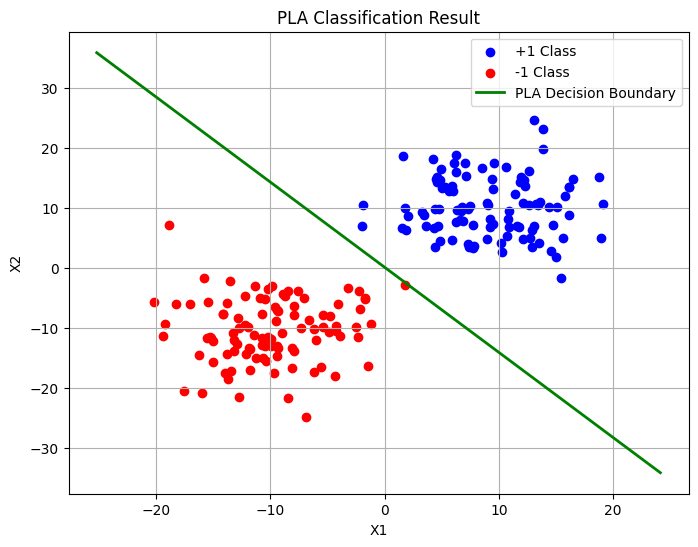

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(x_class_1, y_class_1, c='b', marker='o', label='+1 Class')
plt.scatter(x_class_2, y_class_2, c='r', marker='o', label='-1 Class')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('PLA Classification Result')
plt.grid(True)

# Decision boundary: W0 + W1*x1 + W2*x2 = 0 => x2 = -(W0 + W1*x1)/W2
x_vals = np.linspace(min(X1)-5, max(X1)+5, 200)
y_vals = -(W[0] + W[1]*x_vals) / W[2]
plt.plot(x_vals, y_vals, 'g', linewidth=2, label='PLA Decision Boundary')

plt.legend()
plt.show()